# ASTRA Toolbox Reconstructions 

Notebook for SIRT, and other ASTRA toolbox reconstruction workflows.
* Workflow complied by Ella Kitching
* Last updated 19/07/2024

### Tutorials and guides from ASTRA

* Link to ASTRA documentation : https://astra-toolbox.com/
* ASTRA GitHub for further examples : https://github.com/astra-toolbox/astra-toolbox
* ASTRA intro, video format: https://www.youtube.com/watch?v=VjjH12xC_JE

## Start of Code - Imports

In [1]:
import numpy as np
import astra
from astra.creators import create_vol_geom
from astra.creators import create_proj_geom
from astra.data3d import link
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
from importlib.metadata import version
print(f"ASTRA installation tested is {version('astra-toolbox')}, conda installation")
print(f"numpy installation tested is {version('numpy')}, conda installation")


ASTRA installation tested is 2.2.0, conda installation
numpy installation tested is 1.26.4, conda installation


### Read .npy file and define parameters

In [ ]:
# set path here to npy stack of simulated data
path = ''

In [16]:
data_stack = np.load(path+"dose5e3source3_idpc_stack_-60_65.npy")

In [33]:
print(data_stack.shape) #check axis of stack - if needed swap axes. Format should be X, stack, Y, where rotation is as shown below.

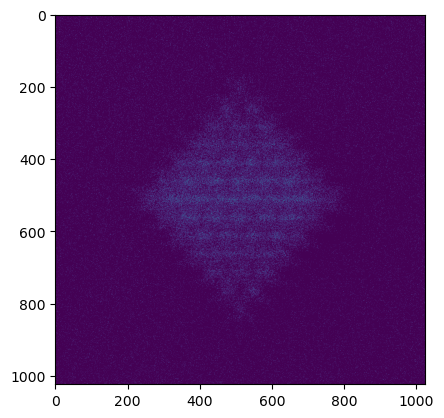

In [34]:
data_swap = np.swapaxes(data_stack, 0, 1)

plt.imshow(data_swap[0])

In [36]:
print(data_stack.dtype)

float32


In [37]:
#read from shape 
X = data_stack.shape[0]
Y = data_stack.shape[1]
Z = data_stack.shape[2]

In [38]:
#define angles in radians from array
start = -60 * (np.pi /180)
end = 65 * (np.pi /180)
num = Y
angles = np.linspace (start, end, num, endpoint =True)
print(angles.shape) # verify number of angles is matched to stack size.

(26,)


### Connecting data to Astra volume and projection geometries

In [39]:
proj_geom = create_proj_geom('parallel3d', 1.0, 1.0, X, Z, angles);

* cone = STEM beam. but can approx to parallel 3d
* 1.0 = distance between the centers of two adjacent detector pixels, horizontal and vertical
* row/col count = image dimensions
* angles: projection angles in radians

In [40]:
vol_geom = create_vol_geom(X, X, Z); 

* n_rows (Y), n_cols (X), n_slices (aka reconstruction thickness), match to shape. 

In [41]:
recdata = astra.data3d.create('-vol', vol_geom)
projdata = astra.data3d.create('-proj3d', proj_geom, data_stack)

In [42]:
iterations = 20

Link to all possible algorithms : https://astra-toolbox.com/docs/algs/index.html

In [43]:
cfg = astra.astra_dict('SIRT3D_CUDA') 
cfg['ReconstructionDataId'] = recdata
cfg['ProjectionDataId'] = projdata
    
alg_id = astra.algorithm.create(cfg)
    
astra.algorithm.run(alg_id, iterations)
    
rec = astra.data3d.get(recdata)
    
astra.algorithm.delete(alg_id)
astra.data3d.delete(recdata)
astra.data3d.delete(projdata)
    

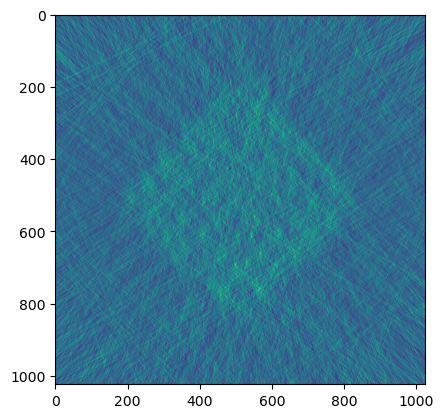

In [44]:
plt.imshow(rec[int((rec.shape[0])/2)])
# Shows central slice of reconstruction result

In [ ]:
save_path = ''

In [45]:
# To convert each slice of reconstruction to png.
import cv2
#change d type to png
rec[rec < 0] = 0
rec /= np.max(rec)
rec = np.round(rec * 255).astype(np.uint8)

detector_rows=X
# Save reconstruction.
for i in range(detector_rows):
    im = rec[i, :, :]
    im = np.flipud(im)
    cv2.imwrite(save_path+r"dose5e3source3_idpc_-60_65_recon_SIRT_iter20_{}.png".format(i), im)
    

In [46]:
# To save reconstruction as a whole python array for post-processing and analysis
np.save(save_path+r'dose5e3source3_idpc_-60_65_recon_SIRT20_reconArray', rec)